# CNN Training for PTM Prediction

Trains a Convolutional Neural Network for protein sequence classification.

## Architecture Overview
- **Input**: One-hot encoded protein sequences (31 amino acids)
- **Embedding**: Optional learned embedding layer
- **Conv Layers**: Multiple 1D convolutional layers to capture local patterns
- **Pooling**: Max pooling for dimensionality reduction
- **Dense Layers**: Fully connected layers for classification
- **Output**: 3 binary predictions (one per PTM type)

## Why CNN for Proteins?
- CNNs excel at detecting local patterns (motifs) in sequences
- Captures position-invariant features
- Efficient with 1D convolutions for sequence data

## Configuration

In [69]:
# ============================================================================
# CONFIGURATION PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# CHANGE THIS for every run to avoid overwriting!
EXPERIMENT_NAME = "run4"

# File paths
TRAIN_FILE = "../output/data_engineered/train_split.csv"
VAL_FILE = "../output/data_engineered/val_split.csv"
OUTPUT_DIR = "../output/cnn/"
EXP_DIR = os.path.join(OUTPUT_DIR, EXPERIMENT_NAME)
os.makedirs(EXP_DIR, exist_ok=True)

# Sequence parameters
SEQ_LENGTH = 31  # All sequences are 31 amino acids
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"  # 20 standard amino acids
VOCAB_SIZE = len(AMINO_ACIDS) + 1  # +1 for padding/unknown

# Model architecture
EMBEDDING_DIM = 64  # Learned embedding dimension
CONV_FILTERS = [128, 256, 256]  # Number of filters per conv layer
KERNEL_SIZES = [3, 3, 3]  # Kernel sizes for conv layers
DROPOUT_RATE = 0.3  # Dropout for regularization
DENSE_UNITS = [128, 64]  # Dense layer sizes

# Training parameters
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 10  # Stop if no improvement for N epochs
DAMPEN_FACTOR = 0.5;

# Class imbalance handling
USE_CLASS_WEIGHTS = True  # Apply class weights for imbalanced data

# Control CPU usage
N_CORES = 16

print("Configuration loaded:")
print(f"  Sequence length: {SEQ_LENGTH}")
print(f"  Vocab size: {VOCAB_SIZE}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Conv filters: {CONV_FILTERS}")
print(f"  Kernel sizes: {KERNEL_SIZES}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Dampening factor: {DAMPEN_FACTOR}")
print(f"  Results will be saved to: {EXP_DIR}")

Configuration loaded:
  Sequence length: 31
  Vocab size: 21
  Embedding dim: 64
  Conv filters: [128, 256, 256]
  Kernel sizes: [3, 3, 3]
  Batch size: 128
  Epochs: 50
  Learning rate: 0.001
  Dampening factor: 0.5
  Results will be saved to: ../output/cnn/run4


## Set Usage Variables

In [70]:
import os

# 1. Set Environment Variables
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["TF_NUM_INTRAOP_THREADS"] = str(N_CORES)
os.environ["TF_NUM_INTEROP_THREADS"] = str(N_CORES)

# 2. Import TensorFlow
import tensorflow as tf

# 3. Configure TensorFlow Threads (Must run immediately after import)
tf.config.threading.set_intra_op_parallelism_threads(N_CORES)
tf.config.threading.set_inter_op_parallelism_threads(N_CORES)

print(f"TensorFlow restricted to {N_CORES} threads.")

TensorFlow restricted to 16 threads.


## Import Libraries

In [71]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import pickle
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.1
GPU available: []


## Load Data

In [72]:
print("="*80)
print("LOADING DATA")
print("="*80)

train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)

label_cols = ["S-glutathionylation", "S-nitrosylation", "S-palmitoylation"]

print(f"\nTrain samples: {len(train_df):,}")
print(f"Val samples: {len(val_df):,}")

# Extract sequences and labels
train_sequences = train_df["Sequence"].values
val_sequences = val_df["Sequence"].values

y_train = train_df[label_cols].values.astype(np.float32)
y_val = val_df[label_cols].values.astype(np.float32)

print(f"\nLabel distribution in training:")
for i, label in enumerate(label_cols):
    pos = y_train[:, i].sum()
    pct = pos / len(y_train) * 100
    print(f"  {label}: {int(pos):,} ({pct:.2f}%)")

LOADING DATA

Train samples: 71,208
Val samples: 17,802

Label distribution in training:
  S-glutathionylation: 3,786 (5.32%)
  S-nitrosylation: 8,845 (12.42%)
  S-palmitoylation: 2,662 (3.74%)


## Sequence Encoding

Convert amino acid sequences to integer indices for embedding layer.

In [73]:
def create_aa_mapping(amino_acids):
    """Create amino acid to integer mapping."""
    aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}  # Start from 1 (0 reserved for padding)
    aa_to_int["X"] = 0  # Unknown/padding
    return aa_to_int

def encode_sequences(sequences, aa_to_int, max_length):
    """Encode sequences as integer arrays."""
    encoded = np.zeros((len(sequences), max_length), dtype=np.int32)
    
    for i, seq in enumerate(sequences):
        for j, aa in enumerate(seq[:max_length]):
            encoded[i, j] = aa_to_int.get(aa, 0)  # 0 for unknown
    
    return encoded

# Create mapping
aa_to_int = create_aa_mapping(AMINO_ACIDS)
print(f"Amino acid mapping created: {len(aa_to_int)} characters")

# Encode sequences
X_train = encode_sequences(train_sequences, aa_to_int, SEQ_LENGTH)
X_val = encode_sequences(val_sequences, aa_to_int, SEQ_LENGTH)

print(f"\nEncoded sequences:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_val shape: {y_val.shape}")

Amino acid mapping created: 21 characters

Encoded sequences:
  X_train shape: (71208, 31)
  X_val shape: (17802, 31)
  y_train shape: (71208, 3)
  y_val shape: (17802, 3)


## Calculate Class Weights

Handle class imbalance by computing weights for each label.

In [74]:
if USE_CLASS_WEIGHTS:
    class_weights_list = []
    
    for i, label in enumerate(label_cols):
        pos_count = y_train[:, i].sum()
        neg_count = len(y_train) - pos_count
        
        # Weight for class 1 (positive)
        pos_weight = (neg_count / pos_count if pos_count > 0 else 1.0) * DAMPEN_FACTOR
        
        class_weights_list.append({0: 1.0, 1: pos_weight})
        print(f"{label}: pos_weight = {pos_weight:.2f}")
    
    print("\n✓ Class weights calculated")
else:
    class_weights_list = None
    print("Class weights disabled")

S-glutathionylation: pos_weight = 8.90
S-nitrosylation: pos_weight = 3.53
S-palmitoylation: pos_weight = 12.87

✓ Class weights calculated


## Build CNN Model

In [75]:
def build_cnn_model(
    vocab_size,
    seq_length,
    embedding_dim,
    conv_filters,
    kernel_sizes,
    dense_units,
    dropout_rate,
    num_labels
):
    """
    Build a CNN model for protein sequence classification.
    
    Architecture:
    - Embedding layer
    - Multiple Conv1D layers with different kernel sizes
    - Max pooling
    - Dense layers
    - Output layer (sigmoid for multi-label)
    """
    inputs = layers.Input(shape=(seq_length,), name="sequence_input")
    
    # Embedding layer
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=seq_length,
        name="embedding"
    )(inputs)
    
    # Multiple conv layers with different kernel sizes
    conv_outputs = []
    for i, (filters, kernel_size) in enumerate(zip(conv_filters, kernel_sizes)):
        conv = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            name=f"conv1d_{i+1}"
        )(x)
        
        # Batch normalization
        conv = layers.BatchNormalization(name=f"bn_conv_{i+1}")(conv)
        
        # Max pooling
        pool = layers.GlobalMaxPooling1D(name=f"pool_{i+1}")(conv)
        conv_outputs.append(pool)
    
    # Concatenate all conv outputs
    if len(conv_outputs) > 1:
        x = layers.Concatenate(name="concat_conv")(conv_outputs)
    else:
        x = conv_outputs[0]
    
    # Dropout
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)
    
    # Dense layers
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = layers.BatchNormalization(name=f"bn_dense_{i+1}")(x)
        x = layers.Dropout(dropout_rate, name=f"dropout_{i+2}")(x)
    
    # Output layer (sigmoid for multi-label classification)
    outputs = layers.Dense(num_labels, activation="sigmoid", name="output")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="PTM_CNN")
    
    return model

# Build model
model = build_cnn_model(
    vocab_size=VOCAB_SIZE,
    seq_length=SEQ_LENGTH,
    embedding_dim=EMBEDDING_DIM,
    conv_filters=CONV_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE,
    num_labels=len(label_cols)
)

print("\n" + "="*80)
print("MODEL ARCHITECTURE")
print("="*80)
model.summary()


MODEL ARCHITECTURE


Model: "PTM_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 31, 64)    │      1,344 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 31, 128)   │     24,704 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 31, 256)   │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 31, 256)   │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv_1           │ (None, 31, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv_2           │ (None, 31, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv_3           │ (None, 31, 256)   │      1,024 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 128)       │          0 │ bn_conv_1[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 256)       │          0 │ bn_conv_2[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 256)       │          0 │ bn_conv_3[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_conv         │ (None, 640)       │          0 │ pool_1[0][0],     │
│ (Concatenate)       │                   │            │ pool_2[0][0],     │
│                     │                   │            │ pool_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 640)       │          0 │ concat_conv[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     82,048 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_dense_1          │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bn_dense_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_dense_2          │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ bn_dense_2[0][0]

 Total params: 218,691 (854.26 KB)

 Trainable params: 217,027 (847.76 KB)

 Non-trainable params: 1,664 (6.50 KB)

## Compile Model

In [76]:
# Use binary crossentropy for multi-label classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "binary_accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

print("✓ Model compiled")

✓ Model compiled


## Setup Callbacks

In [77]:
# Callbacks
callbacks = [
    # Early stopping
    EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    ModelCheckpoint(
        filepath=os.path.join(EXP_DIR, "cnn_model_best.h5"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    
    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks configured")

✓ Callbacks configured


## Train Model

In [78]:
print("\n" + "="*80)
print("TRAINING CNN MODEL")
print("="*80)

# Note: TensorFlow doesn't support per-sample class weights for multi-label
# Instead, we use sample_weight during training
if USE_CLASS_WEIGHTS:
    # Calculate sample weights (max weight across all positive labels)
    sample_weights_train = np.ones(len(y_train))
    for i in range(len(label_cols)):
        pos_mask = y_train[:, i] == 1
        sample_weights_train[pos_mask] = np.maximum(
            sample_weights_train[pos_mask],
            class_weights_list[i][1]
        )
else:
    sample_weights_train = None

# Train
history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    sample_weight=sample_weights_train,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")


TRAINING CNN MODEL
Epoch 1/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.5556 - binary_accuracy: 0.6669 - loss: 1.4702 - precision: 0.0867 - recall: 0.3712
Epoch 1: val_auc improved from None to 0.72721, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - auc: 0.6017 - binary_accuracy: 0.7698 - loss: 1.2970 - precision: 0.1004 - recall: 0.2782 - val_auc: 0.7272 - val_binary_accuracy: 0.9144 - val_loss: 0.3931 - val_precision: 0.2468 - val_recall: 0.0949 - learning_rate: 0.0010
Epoch 2/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.6951 - binary_accuracy: 0.8818 - loss: 1.1146 - precision: 0.1680 - recall: 0.1643
Epoch 2: val_auc improved from 0.72721 to 0.75512, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - auc: 0.7041 - binary_accuracy: 0.8878 - loss: 1.1069 - precision: 0.1748 - recall: 0.1527 - val_auc: 0.7551 - val_binary_accuracy: 0.8938 - val_loss: 0.3828 - val_precision: 0.2292 - val_recall: 0.2042 - learning_rate: 0.0010
Epoch 3/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.7291 - binary_accuracy: 0.8983 - loss: 1.0767 - precision: 0.2008 - recall: 0.1411
Epoch 3: val_auc improved from 0.75512 to 0.77888, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - auc: 0.7337 - binary_accuracy: 0.8998 - loss: 1.0715 - precision: 0.2010 - recall: 0.1342 - val_auc: 0.7789 - val_binary_accuracy: 0.9092 - val_loss: 0.3504 - val_precision: 0.2698 - val_recall: 0.1566 - learning_rate: 0.0010
Epoch 4/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.7467 - binary_accuracy: 0.9004 - loss: 1.0562 - precision: 0.2077 - recall: 0.1361
Epoch 4: val_auc improved from 0.77888 to 0.78286, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - auc: 0.7519 - binary_accuracy: 0.9018 - loss: 1.0491 - precision: 0.2175 - recall: 0.1429 - val_auc: 0.7829 - val_binary_accuracy: 0.9121 - val_loss: 0.3344 - val_precision: 0.2925 - val_recall: 0.1605 - learning_rate: 0.0010
Epoch 5/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.7608 - binary_accuracy: 0.9041 - loss: 1.0146 - precision: 0.2311 - recall: 0.1563
Epoch 5: val_auc improved from 0.78286 to 0.78740, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.7588 - binary_accuracy: 0.9027 - loss: 1.0353 - precision: 0.2281 - recall: 0.1507 - val_auc: 0.7874 - val_binary_accuracy: 0.8916 - val_loss: 0.3578 - val_precision: 0.2618 - val_recall: 0.2824 - learning_rate: 0.0010
Epoch 6/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.7699 - binary_accuracy: 0.9028 - loss: 1.0117 - precision: 0.2397 - recall: 0.1658
Epoch 6: val_auc improved from 0.78740 to 0.79327, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - auc: 0.7670 - binary_accuracy: 0.9023 - loss: 1.0243 - precision: 0.2365 - recall: 0.1634 - val_auc: 0.7933 - val_binary_accuracy: 0.8976 - val_loss: 0.3503 - val_precision: 0.2825 - val_recall: 0.2792 - learning_rate: 0.0010
Epoch 7/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.7797 - binary_accuracy: 0.9012 - loss: 0.9961 - precision: 0.2561 - recall: 0.2009
Epoch 7: val_auc did not improve from 0.79327
557/557 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - auc: 0.7742 - binary_accuracy: 0.9011 - loss: 1.0115 - precision: 0.2485 - recall: 0.1883 - val_auc: 0.7757 - val_binary_accuracy: 0.9074 - val_loss: 0.3177 - val_precision: 0.2720 - val_recall: 0.1746 - learning_rate: 0.0010
Epoch 8/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.7793 - binary_accuracy: 0.9058 - loss: 0.9873 - precision: 0.2585 - recall: 0.1822
Epoch 8: val_auc did not improve from 0.79327
557/557 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - auc: 0.7784 - binary_accuracy: 

557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.7946 - binary_accuracy: 0.8979 - loss: 0.9704 - precision: 0.2592 - recall: 0.2293 - val_auc: 0.7953 - val_binary_accuracy: 0.9067 - val_loss: 0.3093 - val_precision: 0.2882 - val_recall: 0.2058 - learning_rate: 0.0010
Epoch 13/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.8020 - binary_accuracy: 0.8980 - loss: 0.9641 - precision: 0.2659 - recall: 0.2366
Epoch 13: val_auc improved from 0.79533 to 0.80076, saving model to ../output/cnn/run4/cnn_model_best.h5


557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.7994 - binary_accuracy: 0.8992 - loss: 0.9599 - precision: 0.2678 - recall: 0.2355 - val_auc: 0.8008 - val_binary_accuracy: 0.8786 - val_loss: 0.3386 - val_precision: 0.2595 - val_recall: 0.3749 - learning_rate: 0.0010
Epoch 14/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8074 - binary_accuracy: 0.8956 - loss: 0.9467 - precision: 0.2760 - recall: 0.2780
Epoch 14: val_auc did not improve from 0.80076
557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.8040 - binary_accuracy: 0.8960 - loss: 0.9488 - precision: 0.2713 - recall: 0.2681 - val_auc: 0.7930 - val_binary_accuracy: 0.9073 - val_loss: 0.2938 - val_precision: 0.2913 - val_recall: 0.2052 - learning_rate: 0.0010
Epoch 15/50
557/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8091 - binary_accuracy: 0.8941 - loss: 0.9420 - precision: 0.2729 - recall: 0.2838
Epoch 15: val_auc did not improve from 0.80076
557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.8055 - binary_accura

557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.8563 - binary_accuracy: 0.8891 - loss: 0.7955 - precision: 0.3013 - recall: 0.4164 - val_auc: 0.8010 - val_binary_accuracy: 0.8860 - val_loss: 0.2941 - val_precision: 0.2608 - val_recall: 0.3226 - learning_rate: 2.5000e-04
Epoch 31/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8578 - binary_accuracy: 0.8894 - loss: 0.7847 - precision: 0.3016 - recall: 0.4204
Epoch 31: val_auc did not improve from 0.80095
557/557 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - auc: 0.8566 - binary_accuracy: 0.8890 - loss: 0.7948 - precision: 0.3038 - recall: 0.4264 - val_auc: 0.7971 - val_binary_accuracy: 0.8818 - val_loss: 0.2950 - val_precision: 0.2471 - val_recall: 0.3179 - learning_rate: 2.5000e-04
Epoch 32/50
556/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.8598 - binary_accuracy: 0.8887 - loss: 0.7913 - precision: 0.3118 - recall: 0.4417
Epoch 32: val_auc did not improve from 0.80095

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0001250

## Plot Training History

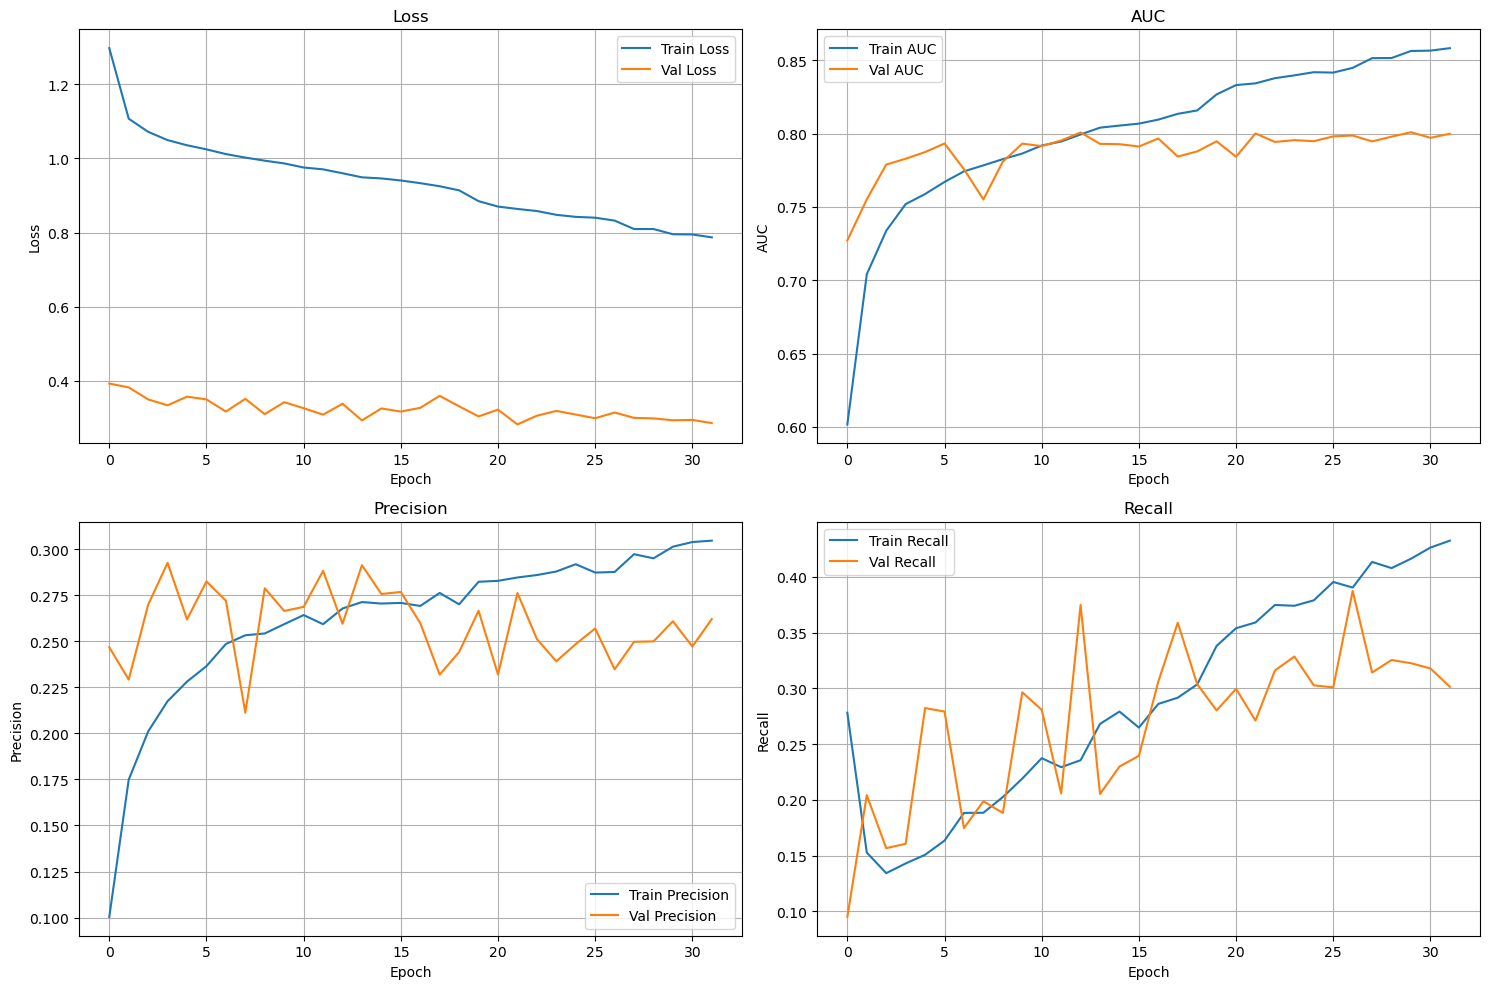

✓ Training history plotted


In [79]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history["loss"], label="Train Loss")
axes[0, 0].plot(history.history["val_loss"], label="Val Loss")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history.history["auc"], label="Train AUC")
axes[0, 1].plot(history.history["val_auc"], label="Val AUC")
axes[0, 1].set_title("AUC")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history["precision"], label="Train Precision")
axes[1, 0].plot(history.history["val_precision"], label="Val Precision")
axes[1, 0].set_title("Precision")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history["recall"], label="Train Recall")
axes[1, 1].plot(history.history["val_recall"], label="Val Recall")
axes[1, 1].set_title("Recall")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, "cnn_training_history.png"), dpi=150)
plt.show()

print("✓ Training history plotted")

## Evaluate Model

In [80]:
print("\n" + "="*80)
print(EXPERIMENT_NAME)
print("EVALUATION ON VALIDATION SET")
print(f"Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Kernel sizes: {KERNEL_SIZES}")
print("="*80)

# Get predictions
y_pred_proba = model.predict(X_val, batch_size=BATCH_SIZE)
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"\n{'Label':<30} {'F1':<12} {'AUC':<12}")
print("-" * 54)

results = {}
for i, label in enumerate(label_cols):
    f1 = f1_score(y_val[:, i], y_pred[:, i])
    auc = roc_auc_score(y_val[:, i], y_pred_proba[:, i])
    results[label] = {"f1": f1, "auc": auc}
    print(f"{label:<30} {f1:<12.4f} {auc:<12.4f}")

macro_f1 = np.mean([r["f1"] for r in results.values()])
macro_auc = np.mean([r["auc"] for r in results.values()])

print(f"\n{'Macro Average':<30} {macro_f1:<12.4f} {macro_auc:<12.4f}")

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
for i, label in enumerate(label_cols):
    print(f"\n[{label}]")
    print(classification_report(
        y_val[:, i],
        y_pred[:, i],
        target_names=["Negative", "Positive"],
        digits=4
    ))


run4
EVALUATION ON VALIDATION SET
Learning rate: 0.001
  Batch size: 128
  Kernel sizes: [3, 3, 3]
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Label                          F1           AUC         
------------------------------------------------------
S-glutathionylation            0.1884       0.7694      
S-nitrosylation                0.2944       0.7539      
S-palmitoylation               0.3255       0.7998      

Macro Average                  0.2695       0.7744      

DETAILED CLASSIFICATION REPORT

[S-glutathionylation]
              precision    recall  f1-score   support

    Negative     0.9540    0.9550    0.9545     16849
    Positive     0.1900    0.1868    0.1884       953

    accuracy                         0.9138     17802
   macro avg     0.5720    0.5709    0.5714     17802
weighted avg     0.9131    0.9138    0.9135     17802


[S-nitrosylation]
              precision    recall  f1-score   support

    Negative     0.8988    0.9063    0.9026     15577
    Pos

## Save Model and Predictions

In [81]:
print("\n" + "="*80)
print("SAVING MODEL AND PREDICTIONS")
print("="*80)

# Save full model
model.save(os.path.join(EXP_DIR, "cnn_model_final.h5"))
print(f"✓ Saved cnn_model_final.h5")

# Save validation predictions (for ensemble)
val_pred_df = pd.DataFrame({
    "ID": val_df["ID"],
    "cnn_glut_proba": y_pred_proba[:, 0],
    "cnn_nitro_proba": y_pred_proba[:, 1],
    "cnn_palm_proba": y_pred_proba[:, 2]
})
val_pred_df.to_csv(os.path.join(EXP_DIR, "cnn_val_predictions.csv"), index=False)
print(f"✓ Saved cnn_val_predictions.csv")

# Save results
results_df = pd.DataFrame(results).T
results_df.to_csv(os.path.join(EXP_DIR, "cnn_results.csv"))
print(f"✓ Saved cnn_results.csv")

# Save amino acid mapping (needed for test predictions)
with open(os.path.join(EXP_DIR, "aa_to_int.pkl"), "wb") as f:
    pickle.dump(aa_to_int, f)
print(f"✓ Saved aa_to_int.pkl")

print("\n" + "="*80)
print("✓ CNN TRAINING COMPLETE!")
print("="*80)
print(f"\nFinal Performance:")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  Macro AUC: {macro_auc:.4f}")
print(f"\nNext steps:")
print(f"  1. Share cnn_val_predictions.csv with teammates for ensemble")
print(f"  2. Use cnn_model_final.h5 for test predictions")
print(f"  3. Consider hyperparameter tuning if performance is suboptimal")
print("="*80)


SAVING MODEL AND PREDICTIONS
✓ Saved cnn_model_final.h5
✓ Saved cnn_val_predictions.csv
✓ Saved cnn_results.csv
✓ Saved aa_to_int.pkl

✓ CNN TRAINING COMPLETE!

Final Performance:
  Macro F1: 0.2695
  Macro AUC: 0.7744

Next steps:
  1. Share cnn_val_predictions.csv with teammates for ensemble
  2. Use cnn_model_final.h5 for test predictions
  3. Consider hyperparameter tuning if performance is suboptimal


## Optional: Predict on Test Data

Uncomment and run this cell when you have test data ready.

In [82]:
# # Load test data
# test_df = pd.read_csv("../data/test.csv")
# test_sequences = test_df["Sequence"].values
# 
# # Encode test sequences
# X_test = encode_sequences(test_sequences, aa_to_int, SEQ_LENGTH)
# 
# # Predict
# test_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE)
# 
# # Save predictions
# test_pred_df = pd.DataFrame({
#     "ID": test_df["ID"],
#     "cnn_glut_proba": test_pred_proba[:, 0],
#     "cnn_nitro_proba": test_pred_proba[:, 1],
#     "cnn_palm_proba": test_pred_proba[:, 2]
# })
# test_pred_df.to_csv(os.path.join(OUTPUT_DIR, "cnn_test_predictions.csv"), index=False)
# print("✓ Saved cnn_test_predictions.csv")